In [1]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import polars as pl
import matplotlib.pyplot as plt
import os
import numpy as np
import matplotlib.animation as animation

In [4]:
class LearningAnimation():
    
    saved_dfs = {}
    
    def __init__(self,
                    evtf:str = '/scratch/tsoies-Expression/runs/expression/random_enformer/20260228-233356/events.out.tfevents.1772296451.hydra-gpu3.ipa.icgbio.ru.1859263.0',
                    evtf_path:str = 'pearson_corr_genes_Homo sapiens/iterations/',
                    loggingInterval:int = 50,
                    species:str = 'Homo sapiens',
                    model_path:str = '/scratch/tsoies-Expression/runs/expression/random_enformer/20260228-233356',
                    seed:int|None = 42,
                    sample_size:int|None = None,
                    use_precomputed_geneCorr:bool=True,
                    minTPM:float|None = None,
                    maxTPM:float|None = None):
        self.evtf = evtf
        self.evtf_path = evtf_path
        self.model_path = model_path
        self.loggingInterval = loggingInterval
        self.species = species
        self.sample_size = sample_size
        self.seed = seed
        self.use_precomputed_geneCorr = use_precomputed_geneCorr
        self.minTPM = minTPM
        self.maxTPM = maxTPM
        
        
        
        
    def make_step2corr(self, max_step:int, split:str):
        event_acc = EventAccumulator(self.evtf)
        event_acc.Reload()
        scal_corr = event_acc.Scalars(self.evtf_path+split)
        df = pl.DataFrame([{'step':record.step, 'value':record.value} for record in scal_corr])
        if max_step:
            df = df.filter(pl.col('step') <= max_step)
        return df

    def make_predictsVStargets(self,
                                step:int,
                                split:str
                                ):
        if split=='valid':
            file_idx = int(step/self.loggingInterval + 1) + int(step/self.loggingInterval + 1)
        elif split=='train':
            file_idx = int(step/self.loggingInterval + 1) + int(step/self.loggingInterval + 1) - 1 
        else:
            raise ValueError('wrong value for split')
        labels_file = os.path.join(self.model_path, f'labels_{file_idx}.csv')
        labels_df = pl.read_csv(labels_file)
        if self.sample_size:
            labels_df = labels_df.sample(self.sample_size, seed=self.seed if self.seed else None)
        return labels_df
    
    def compute_geneCorr(self, max_step:int|None, split:str, minTPM:float|None, maxTPM:float|None):
        
        df_name = f'{split}_{minTPM}_{maxTPM}'
        if df_name not in LearningAnimation.saved_dfs:
            step2corr_list = []
            step = 0
            while True:
                try:
                    predictsVStargets = self.make_predictsVStargets(step=step, split=split).filter(pl.col('dataset_description') == 'Homo sapiens')
                    predictsVStargets = predictsVStargets.filter(~pl.col('tpm_true').is_null() & ~pl.col('tpm_pred').is_null())
                    if minTPM:
                        predictsVStargets = predictsVStargets.filter(pl.col('tpm_true') > minTPM)
                    if maxTPM:
                        predictsVStargets = predictsVStargets.filter(pl.col('tpm_pred') < maxTPM)
                    geneCorr = np.corrcoef(predictsVStargets['tpm_true'], predictsVStargets['tpm_pred'])[0,1]
                    step2corr_list.append({'step':step, 'value':geneCorr})
                    step += self.loggingInterval
                except:
                    LearningAnimation.saved_dfs[df_name] = pl.DataFrame(step2corr_list)
                    break
        if max_step:
            return LearningAnimation.saved_dfs[df_name].filter(pl.col('step')<=max_step)
        else:
            return LearningAnimation.saved_dfs[df_name]
    
    def _plot_step(self, frame: int):
        step = frame * self.loggingInterval
    
        # Clear the axes for updating
        for ax in self.axs.flat:
            ax.clear()
    
        labels_df_valid = self.make_predictsVStargets(step=step, split='valid')
        labels_human_valid = labels_df_valid.filter(pl.col('dataset_description') == 'Homo sapiens')
        labels_rest_valid = labels_df_valid.filter(pl.col('dataset_description') != 'Homo sapiens')
    
        labels_df_train = self.make_predictsVStargets(step=step, split='train')
        labels_human_train = labels_df_train.filter(pl.col('dataset_description') == 'Homo sapiens')
        labels_rest_train = labels_df_train.filter(pl.col('dataset_description') != 'Homo sapiens')
    
        if self.use_precomputed_geneCorr:
            step2corr_valid = self.make_step2corr(max_step=step, split='valid')
            step2corr_train = self.make_step2corr(max_step=step, split='train')
        else:
            step2corr_valid = self.compute_geneCorr(max_step=step, split='valid', minTPM=self.minTPM, maxTPM=self.maxTPM)
            step2corr_train = self.compute_geneCorr(max_step=step, split='train', minTPM=self.minTPM, maxTPM=self.maxTPM)
    
        # --- Helper to create masks based on minTPM/maxTPM ---
        def inside_mask(df):
            cond = pl.lit(True)
            if self.minTPM is not None:
                cond = cond & (pl.col('tpm_true') >= self.minTPM)
            if self.maxTPM is not None:
                cond = cond & (pl.col('tpm_true') <= self.maxTPM)
            return cond
    
        # Split each subset into inside/outside
        # valid
        mask_human_valid_inside = inside_mask(labels_human_valid)
        df_human_valid_inside = labels_human_valid.filter(mask_human_valid_inside)
        df_human_valid_outside = labels_human_valid.filter(~mask_human_valid_inside)
    
        mask_rest_valid_inside = inside_mask(labels_rest_valid)
        df_rest_valid_inside = labels_rest_valid.filter(mask_rest_valid_inside)
        df_rest_valid_outside = labels_rest_valid.filter(~mask_rest_valid_inside)
    
        # train
        mask_human_train_inside = inside_mask(labels_human_train)
        df_human_train_inside = labels_human_train.filter(mask_human_train_inside)
        df_human_train_outside = labels_human_train.filter(~mask_human_train_inside)
    
        mask_rest_train_inside = inside_mask(labels_rest_train)
        df_rest_train_inside = labels_rest_train.filter(mask_rest_train_inside)
        df_rest_train_outside = labels_rest_train.filter(~mask_rest_train_inside)
    
        # --- Plot VALID correlation (unchanged) ---
        self.axs[0, 0].plot(step2corr_valid['step'], step2corr_valid['value'])
        max_corr_valid = step2corr_valid['value'].max()
        max_corr_step_valid = step2corr_valid.filter(pl.col('value') == max_corr_valid)['step'].item(0)
        self.axs[0, 0].scatter(x=[max_corr_step_valid], y=[max_corr_valid], c='r', label='max correlation')
        self.axs[0, 0].set_xlabel('iteration')
        self.axs[0, 0].set_ylabel('correlation')
        last_corr_valid = step2corr_valid.select(pl.last('value')).item()
        self.axs[0, 0].set_title(f'Correlation VALID, max: {round(max_corr_valid, 3)} | current: {round(last_corr_valid, 3)}')
    
        # --- Plot TRAIN correlation (unchanged) ---
        self.axs[1, 0].plot(step2corr_train['step'], step2corr_train['value'])
        max_corr_train = step2corr_train['value'].max()
        max_corr_step_train = step2corr_train.filter(pl.col('value') == max_corr_train)['step'].item(0)
        self.axs[1, 0].scatter(x=[max_corr_step_train], y=[max_corr_train], c='r', label='max correlation')
        self.axs[1, 0].set_xlabel('iteration')
        self.axs[1, 0].set_ylabel('correlation')
        last_corr_train = step2corr_train.select(pl.last('value')).item()
        self.axs[1, 0].set_title(f'Correlation TRAIN, max: {round(max_corr_train, 2)} | current: {round(last_corr_train, 2)}')
    
        # --- Plot VALID scatter with highlighting ---
        # Outside points (faint)
        if len(df_rest_valid_outside) > 0:
            self.axs[0, 1].scatter(x=df_rest_valid_outside['tpm_true'], y=df_rest_valid_outside['tpm_pred'],
                                   s=0.4, alpha=0.2)
        if len(df_human_valid_outside) > 0:
            self.axs[0, 1].scatter(x=df_human_valid_outside['tpm_true'], y=df_human_valid_outside['tpm_pred'],
                                   s=0.4, alpha=0.4, c='r')
        # Inside points (normal visibility)
        if len(df_rest_valid_inside) > 0:
            self.axs[0, 1].scatter(x=df_rest_valid_inside['tpm_true'], y=df_rest_valid_inside['tpm_pred'],
                                   s=0.6, alpha=0.2, c='g', label='non-human')
        if len(df_human_valid_inside) > 0:
            self.axs[0, 1].scatter(x=df_human_valid_inside['tpm_true'], y=df_human_valid_inside['tpm_pred'],
                                   s=0.6, alpha=0.4, c='r', label='human')
    
        self.axs[0, 1].set_xlabel('TPM TRUE')
        self.axs[0, 1].set_ylabel('TPM PREDICTED')
        self.axs[0, 1].set_title('true vs pred VALID')
        self.axs[0, 1].plot(np.arange(0, 10, 0.01), np.arange(0, 10, 0.01), c='y', lw=1, label='y=x')
        self.axs[0, 1].legend(loc='upper left', fontsize='small')
        self.axs[0, 1].set_ylim(-0.1, 8)
        self.axs[0, 1].set_xlim(-0.1, 8)
    
        # --- Plot TRAIN scatter with highlighting ---
        # Outside points
        if len(df_rest_train_outside) > 0:
            self.axs[1, 1].scatter(x=df_rest_train_outside['tpm_true'], y=df_rest_train_outside['tpm_pred'],
                                   s=0.4, alpha=0.2)
        if len(df_human_train_outside) > 0:
            self.axs[1, 1].scatter(x=df_human_train_outside['tpm_true'], y=df_human_train_outside['tpm_pred'],
                                   s=0.4, alpha=0.4, c='r')
        # Inside points
        if len(df_rest_train_inside) > 0:
            self.axs[1, 1].scatter(x=df_rest_train_inside['tpm_true'], y=df_rest_train_inside['tpm_pred'],
                                   s=0.6, alpha=0.2, c='g', label='non-human')
        if len(df_human_train_inside) > 0:
            self.axs[1, 1].scatter(x=df_human_train_inside['tpm_true'], y=df_human_train_inside['tpm_pred'],
                                   s=0.6, alpha=0.4, c='r', label='human')
    
        self.axs[1, 1].set_xlabel('TPM TRUE')
        self.axs[1, 1].set_ylabel('TPM PREDICTED')
        self.axs[1, 1].set_title('true vs pred TRAIN')
        self.axs[1, 1].plot(np.arange(0, 10, 0.01), np.arange(0, 10, 0.01), c='y', lw=1, label='y=x')
        self.axs[1, 1].legend(loc='upper left', fontsize='small')
        self.axs[1, 1].set_ylim(-0.1, 8)
        self.axs[1, 1].set_xlim(-0.1, 8)
    
        return self.axs.flat

    def animate(self, num_frames:int, interval:int, show:bool = False, save:bool=False):
        # Create the figure and axes outside the function
        self.fig, self.axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 10), squeeze=False)

        # Create the animation
        ani = animation.FuncAnimation(
            fig=self.fig, 
            func=self._plot_step, 
            frames=num_frames, 
            interval=interval,
            blit=False 
        )
        if save:
            ani.save(f'/scratch/tsoies-Expression/GENA_LM/downstream_tasks/expression_prediction/anim_{self.minTPM}_{self.maxTPM}_{num_frames}.mp4')
            plt.close()
            
        if show:
            from IPython.display import HTML
            return HTML(ani.to_html5_video())
        return ani
    
    

In [6]:
LearningAnimation(maxTPM=2, use_precomputed_geneCorr=False).compute_geneCorr(max_step=None, split='train', maxTPM=2, minTPM=None)

step,value
i64,f64
0,0.145659
50,-0.006473
100,0.065136
150,0.11969
200,0.232592
…,…
6450,0.694084
6500,0.668235
6550,0.724785


In [5]:
LearningAnimation.saved_dfs

{}

In [6]:
LearningAnimation(maxTPM=2, use_precomputed_geneCorr=False).animate(num_frames=207, interval=500, save=True)

In [7]:
LearningAnimation(maxTPM=4, minTPM=2, use_precomputed_geneCorr=False).animate(num_frames=207, interval=500, save=True)

In [8]:
LearningAnimation(minTPM=4, use_precomputed_geneCorr=False).animate(num_frames=207, interval=500, save=True)

In [9]:
LearningAnimation(use_precomputed_geneCorr=False).animate(num_frames=207, interval=500, save=True)

In [19]:
def make_step2corr(step:int|None,
                evtf:str = '/scratch/tsoies-Expression/runs/expression/random_enformer/20260228-233356/events.out.tfevents.1772296451.hydra-gpu3.ipa.icgbio.ru.1859263.0',
                path:str = 'pearson_corr_genes_Homo sapiens/iterations/',
                loggingInterval:int=50,
                split:str='valid'):
    event_acc = EventAccumulator(evtf)
    event_acc.Reload()
    scal_corr = event_acc.Scalars(path+split)
    df = pl.DataFrame([{'step':record.step, 'value':record.value} for record in scal_corr])
    if step:
        df = df.filter(pl.col('step') <= step)
    return df

In [5]:
make_step2corr(4500)

step,value
i64,f64
0,0.051248
50,0.007457
100,0.354675
150,0.347026
200,0.433062
…,…
4300,0.607204
4350,0.608525
4400,0.604222


In [12]:
for i in range(10):
    print(i+i-1)

-1
1
3
5
7
9
11
13
15
17


In [20]:
def make_predictsVStargets(step:int, 
                            logdir:str='/scratch/tsoies-Expression/runs/expression/random_enformer/20260228-233356',
                            species:str='Homo sapiens',
                            loggingInterval:int=50,
                            sample_size:int|None = None,
                            seed:int=42,
                            split:str='valid'):
    if split=='valid':
        file_idx = int(step/loggingInterval + 1) + int(step/loggingInterval + 1)
    elif split=='train':
        file_idx = int(step/loggingInterval + 1) + int(step/loggingInterval + 1) -1 
    else:
        raise ValueError('wrong value for split')
    labels_file = os.path.join(logdir, f'labels_{file_idx}.csv')
    labels_df = pl.read_csv(labels_file)
    if sample_size:
        labels_df = labels_df.sample(sample_size, seed=seed)
    return labels_df

In [51]:
a = make_predictsVStargets(7200, split='valid')

In [ ]:
.filter((pl.col('tpm_true') > 0) & (pl.col('tpm_pred')>0))

False

In [73]:
np.corrcoef(a['tpm_true'], a['tpm_pred'])[0,1]

0.5852307073763575

In [ ]:
def geneCorr():
    

In [11]:
def plot_step(frame: int):
    step = frame * 50
    
    # Clear the axes for updating
    for ax in axs.flat:
        ax.clear()
    
    labels_df_valid = make_predictsVStargets(step=step, split='valid')
    labels_human_valid = labels_df_valid.filter(pl.col('dataset_description') == 'Homo sapiens')
    labels_rest_valid = labels_df_valid.filter(pl.col('dataset_description') != 'Homo sapiens')
    
    labels_df_train = make_predictsVStargets(step=step, split='train')
    labels_human_train = labels_df_train.filter(pl.col('dataset_description') == 'Homo sapiens')
    labels_rest_train = labels_df_train.filter(pl.col('dataset_description') != 'Homo sapiens')
    
    step2corr_valid = make_step2corr(step=step, split='valid')
    step2corr_train = make_step2corr(step=step, split='train')
    
    # Plot VALID correlation
    axs[0, 0].plot(step2corr_valid['step'], step2corr_valid['value'])
    max_corr_valid = step2corr_valid['value'].max()
    max_corr_step_valid = step2corr_valid.filter(pl.col('value') == max_corr_valid)['step'].item()
    axs[0, 0].scatter(x=[max_corr_step_valid], y=[max_corr_valid], c='r', label='max correlation')
    axs[0, 0].set_xlabel('iteration')
    axs[0, 0].set_ylabel('correlation')
    last_corr_valid = step2corr_valid.select(pl.last('value')).item()
    axs[0, 0].set_title(f'Correlation VALID, max: {round(max_corr_valid, 3)} | current: {round(last_corr_valid, 3)}')
    
    # Plot TRAIN correlation
    axs[1, 0].plot(step2corr_train['step'], step2corr_train['value'])
    max_corr_train = step2corr_train['value'].max()
    max_corr_step_train = step2corr_train.filter(pl.col('value') == max_corr_train)['step'].item()
    axs[1, 0].scatter(x=[max_corr_step_train], y=[max_corr_train], c='r', label='max correlation')
    axs[1, 0].set_xlabel('iteration')
    axs[1, 0].set_ylabel('correlation')
    last_corr_train = step2corr_train.select(pl.last('value')).item()
    axs[1, 0].set_title(f'Correlation TRAIN, max: {round(max_corr_train, 2)} | current: {round(last_corr_train, 2)}')
    
    # Plot VALID scatter
    axs[0, 1].scatter(x=labels_rest_valid['tpm_true'], y=labels_rest_valid['tpm_pred'], 
                     s=0.6, alpha=0.2, label='non-human')
    axs[0, 1].scatter(x=labels_human_valid['tpm_true'], y=labels_human_valid['tpm_pred'], 
                     s=0.6, alpha=0.4, c='r', label='human')
    axs[0, 1].set_xlabel('TPM TRUE')
    axs[0, 1].set_ylabel('TPM PREDICTED')
    axs[0, 1].set_title('true vs pred VALID')
    axs[0, 1].plot(np.arange(0, 10, 0.01), np.arange(0, 10, 0.01), c='y', lw=1, label='y=x')
    axs[0, 1].legend(loc='upper left', fontsize='small')
    axs[0, 1].set_ylim(-0.1, 8)
    axs[0, 1].set_xlim(-0.1, 8)
    
    # Plot TRAIN scatter
    axs[1, 1].scatter(x=labels_rest_train['tpm_true'], y=labels_rest_train['tpm_pred'], 
                     s=0.6, alpha=0.2, label='non-human')
    axs[1, 1].scatter(x=labels_human_train['tpm_true'], y=labels_human_train['tpm_pred'], 
                     s=0.6, alpha=0.4, c='r', label='human')
    axs[1, 1].set_xlabel('TPM TRUE')
    axs[1, 1].set_ylabel('TPM PREDICTED')
    axs[1, 1].set_title('true vs pred TRAIN')
    axs[1, 1].plot(np.arange(0, 10, 0.01), np.arange(0, 10, 0.01), c='y', lw=1, label='y=x')
    axs[1, 1].legend(loc='upper left', fontsize='small')
    axs[1, 1].set_ylim(-0.1, 8)
    axs[1, 1].set_xlim(-0.1, 8)
    
    # Return all artists that have changed (optional, but good practice)
    return axs.flat

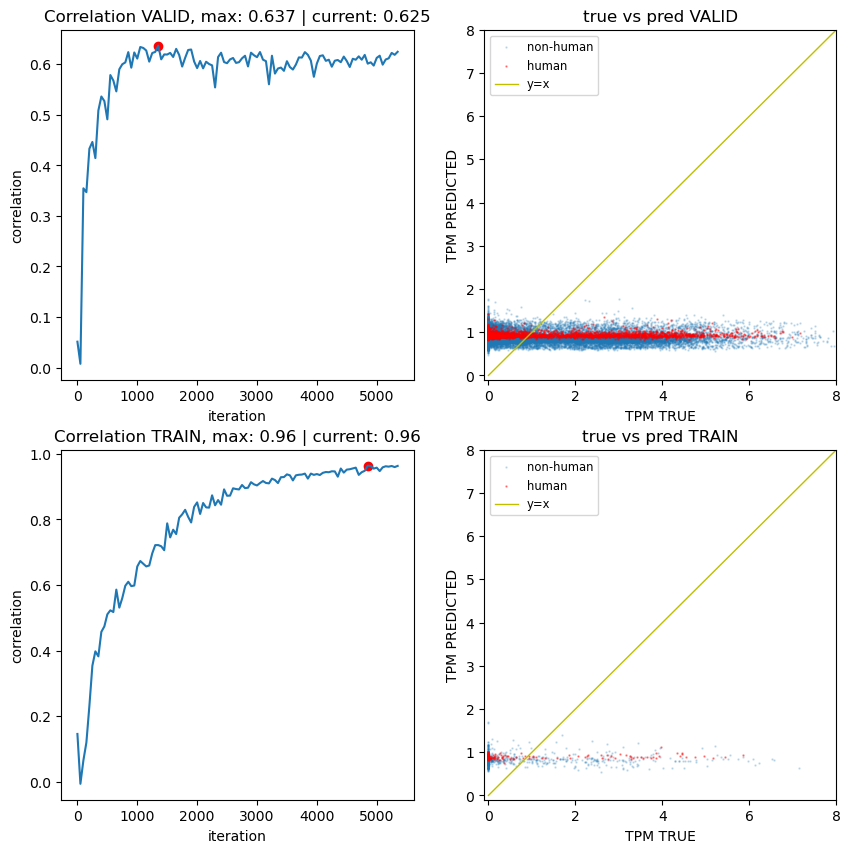

In [65]:
# Create the figure and axes outside the function
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 10), squeeze=False)

# Create the animation
ani = animation.FuncAnimation(
    fig=fig, 
    func=plot_step, 
    frames=100, 
    interval=500,
    blit=False  # Set to True only if you return artists and want blitting
)

In [ ]:
# To display in Jupyter notebook
from IPython.display import HTML
HTML(ani.to_html5_video())

<Figure size 640x480 with 0 Axes>

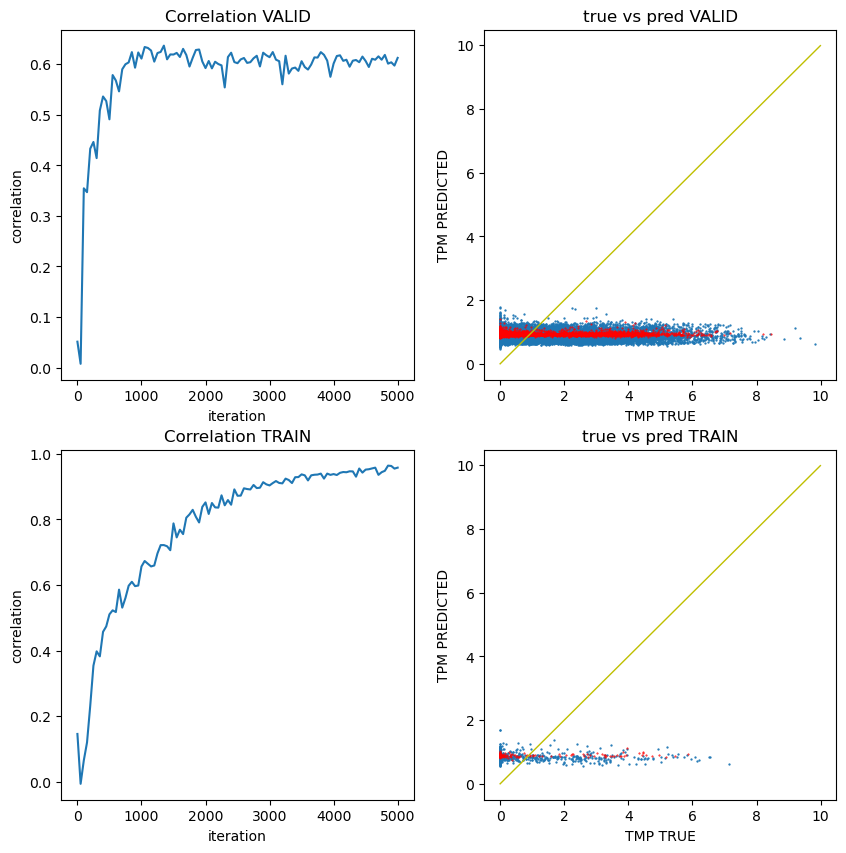

In [34]:
fig = plt.figure()
ani = animation.FuncAnimation(fig=fig, func=plot_step, frames=100, interval=200)

In [18]:
ani.save('/scratch/tsoies-Expression/anim.mp4')
plt.close()